In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import random

from modules import background_model, ModelDataSet, SequenceRepresentation

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

2025-06-19 19:54:29.974065: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:54:29.986291: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-19 19:54:30.112483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-19 19:54:32.344048: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def from_one_hot(X, k):
    """Convert one-hot encoded tensor to string representation."""
    import itertools
    alphabet = [''.join(p) for p in itertools.product([c for c in 'ACGT'], repeat=k)]
    assert X.shape[-1] == 4**k, "Last dimension must match 4^k for k-mer encoding"
    assert len(X.shape) == 6, "Input tensor must be 6D: (batch_size, tiles_per_X, N, f, tile_size, alphabet_size)"
    for b in range(X.shape[0]):
        for t in range(X.shape[1]):
            for n in range(X.shape[2]):
                for f in range(X.shape[3]):
                    oh = X[b, t, n, f, :, :]
                    idcs = [np.argmax(oh[j,:]) if np.max(oh[j,:]) != 0 else -1 \
                            for j in range(oh.shape[0])]
                    seq = ' '.join([ alphabet[i] if i != -1 else 'N' for i in idcs ])
                    print(f"Batch {b}, Tile {t}, Sequence {n}, Frame {f}: {seq}")
    #return ''.join(['ACGT'[np.argmax(x)] for x in X])

In [3]:
# quick test of k-mer dataset
raw_data = [
    'ACGT',
    'AACCGGTT',
    'TAACGTAG'
]
data = ModelDataSet.ModelDataSet(
    [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=s)]) \
                                   for i, s in enumerate(raw_data)],
    ModelDataSet.DataMode.DNA,
    tile_size=8,
    tiles_per_X=1,
    batch_size=1,
    prefetch=1,
)

ds = data.getDataset(k=1)
for X, _ in ds:
    assert X.shape == (1,1,3,2,8,4)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 1)
    break

(1, 1, 3, 2, 8, 4)
[[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [0. 0. 0. 1.]]

 [[0. 0. 0. 1.]
  [1. 0. 0. 0.]
  [1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [1. 0. 0. 0.]
  [0. 0. 1. 0.]]]
Batch 0, Tile 0, Sequence 0, Frame 0: A C G T N N N N
Batch 0, Tile 0, Sequence 0, Frame 1: A C G T N N N N
Batch 0, Tile 0, Sequence 1, Frame 0: A A C C G G T T
Batch 0, Tile 0, Sequence 1, Frame 1: A A C C G G T T
Batch 0, Tile 0, Sequence 2, Frame 0: T A A C G T A G
Batch 0, Tile 0, Sequence 2, Frame 1: C T A C G T T A


In [4]:
ds = data.getDataset(k=2)
for X, _ in ds:
    assert X.shape == (1,1,3,2,7,16), f"Expected shape {(1,1,2,2,7,16)}, got {X.shape}"  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X, 2)  # Convert to string representation
    break

(1, 1, 3, 2, 7, 16)
[[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0

In [5]:
ds = data.getDataset(k=3)
for X, _ in ds:
    assert X.shape == (1,1,3,2,6,64)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 3)  # Convert to string representation
    break

(1, 1, 3, 2, 6, 64)
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Batch 0, Tile 0, Sequence 0, Frame 0: ACG CGT N N N N
Batch 0, Tile 0, Sequence 0, Frame 1: ACG CGT N N N N
Batch 0, Tile 0, Sequence 1, Frame 0: AAC ACC CCG CGG GGT GTT
Batch 0, Tile 0, Sequence 1, Frame 1: AAC ACC CCG CGG GGT GTT
Batch 0, Tile 0, Sequence 2, Frame 0: TAA AAC ACG CGT GTA TAG
Batch 0, Tile 0, Sequence 2, Frame 1: CTA TAC ACG CGT GTT TTA


---

In [6]:
N = 1000
seqlen = 100
tile_size = 100
batch_size = 1# 32
K = 1

In [7]:
def generate_data(model: np.ndarray, N: int, seqlen: int, tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = np.zeros(len(alphabet), dtype=int)
    for seq in raw_data:
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = counts / np.sum(counts)
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data: {relative_frequencies}")
            
    return data, relative_frequencies

In [8]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [9]:
def single_model_test(ground_truth: np.ndarray, name: str, lr: float = 0.1, epochs: int = 50,
                      N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, batch_size: int = batch_size, 
                      K: int = 1, perfect_initialization: bool = False):
    """ 
    K: since there is only one ground truth, by default learn only one model. However, it might make sense to learn
       two models for unbalanced ground truths, as the data contains both the fwd and rc sequences which will have
       opposing distributions. In this case, try setting K to 2.
    perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    logging.info(f"Testing model {name} with parameters: {ground_truth} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_data(ground_truth, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        assert K == 1, f"[single_model_test] perfect_initialization is not supported with {K=} != 1"
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.expand_dims(np.log(relative_frequencies), -1))
        model.m_logit.assign([1.0])  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(data, lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init},\n\nTrained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init},\n\nTrained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")

2025-06-19 19:45:09,586 - INFO - Testing model Uniform Distribution with parameters: [0.25 0.25 0.25 0.25] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:45:10,052 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:45:10,087 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.2505 0.2488 0.2501 0.2506]
2025-06-19 19:45:10,097 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:45:10,114 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:45:10,131 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-19 19:45:11.537406: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:45:11,541 - INFO - [background_model.train] >>> epoch     0 mean loss = 277697.0625, time: 1.41s
2025-06-19 19:45:11,541 - DEBUG - [background_model.t

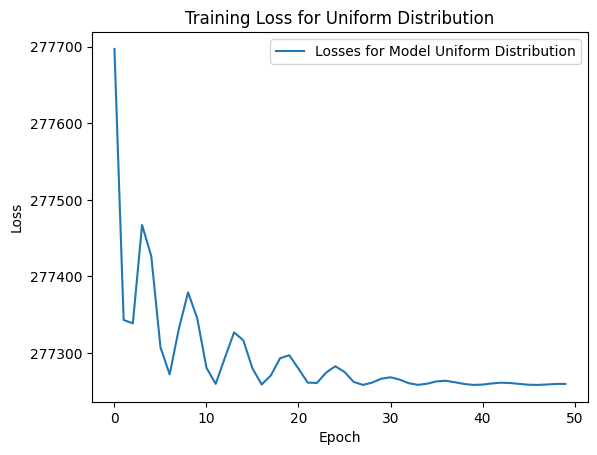

2025-06-19 19:45:42,944 - INFO - Initial Q (logit/softmax):
[[ 0.0329]
 [-0.0118]
 [-0.0294]
 [-0.0071]]

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]],

Trained Q (logit/softmax):
[[0.0177]
 [0.0079]
 [0.0032]
 [0.0109]]

[[0.252 ]
 [0.2495]
 [0.2483]
 [0.2502]]
2025-06-19 19:45:42,945 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-19 19:45:42,946 - INFO - Relative frequencies of nucleotides in generated data:
[0.2505 0.2488 0.2501 0.2506]


In [10]:
single_model_test(ground_truth_1, "Uniform Distribution")

2025-06-19 19:45:42,957 - INFO - Testing model Uniform Distribution perfect init with parameters: [0.25 0.25 0.25 0.25] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:45:43,474 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:45:43,517 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.2503 0.2484 0.249  0.2524]
2025-06-19 19:45:43,528 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:45:43,549 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:45:43,571 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-19 19:45:44.884064: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:45:44,891 - INFO - [background_model.train] >>> epoch     0 mean loss = 277261.8750, time: 1.32s
2025-06-19 19:45:44,892 - DEBUG - [bac

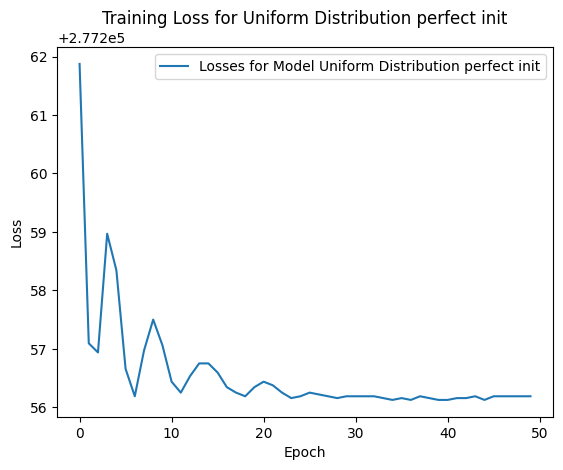

2025-06-19 19:46:18,385 - INFO - Initial Q (logit/softmax):
[[-1.3853]
 [-1.3926]
 [-1.3905]
 [-1.3769]]

[[0.2503]
 [0.2484]
 [0.249 ]
 [0.2524]],

Trained Q (logit/softmax):
[[-1.3805]
 [-1.3922]
 [-1.392 ]
 [-1.3806]]

[[0.2515]
 [0.2485]
 [0.2486]
 [0.2514]]
2025-06-19 19:46:18,387 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-19 19:46:18,389 - INFO - Relative frequencies of nucleotides in generated data:
[0.2503 0.2484 0.249  0.2524]


In [11]:
single_model_test(ground_truth_1, "Uniform Distribution perfect init", lr=0.01, perfect_initialization=True)

2025-06-19 19:46:18,407 - INFO - Testing model Non-Uniform Distribution 1 with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=5, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:46:19,026 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:46:19,069 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.0996 0.1989 0.3008 0.4007]
2025-06-19 19:46:19,078 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:46:19,099 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:46:19,122 - DEBUG - [model.train.setLR] >>> Setting learning rate to 5
2025-06-19 19:46:20.341358: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:46:20,345 - INFO - [background_model.train] >>> epoch     0 mean loss = 717588.3750, time: 1.22s
2025-06-19 19:46:20,346 - DEBUG - [background_model.tra

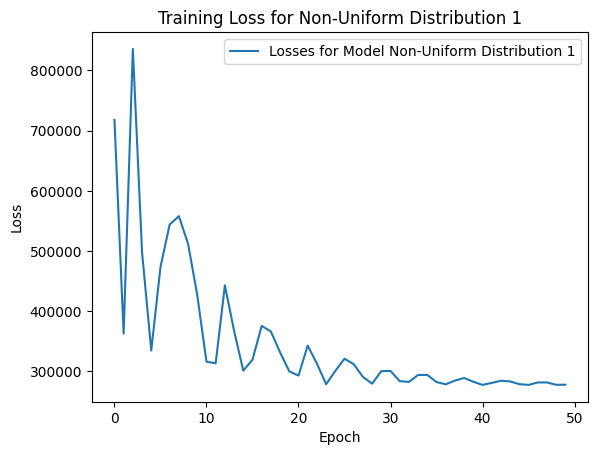

2025-06-19 19:46:52,987 - INFO - Initial Q (logit/softmax):
[[ 0.0329]
 [-0.0118]
 [-0.0294]
 [-0.0071]]

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]],

Trained Q (logit/softmax):
[[0.1794]
 [0.3879]
 [0.2934]
 [0.4031]]

[[0.2172]
 [0.2676]
 [0.2435]
 [0.2717]]
2025-06-19 19:46:52,989 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-19 19:46:52,990 - INFO - Relative frequencies of nucleotides in generated data:
[0.0996 0.1989 0.3008 0.4007]


In [12]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1", lr=5)

2025-06-19 19:46:53,007 - INFO - Testing model Non-Uniform Distribution 1 perfect init with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:46:53,718 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:46:53,769 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.1001 0.2004 0.297  0.4025]
2025-06-19 19:46:53,776 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:46:53,797 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:46:53,827 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-19 19:46:55.049361: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:46:55,055 - INFO - [background_model.train] >>> epoch     0 mean loss = 300963.6875, time: 1.22s
2025-06-19 19:46:55,057 - DEBUG - [b

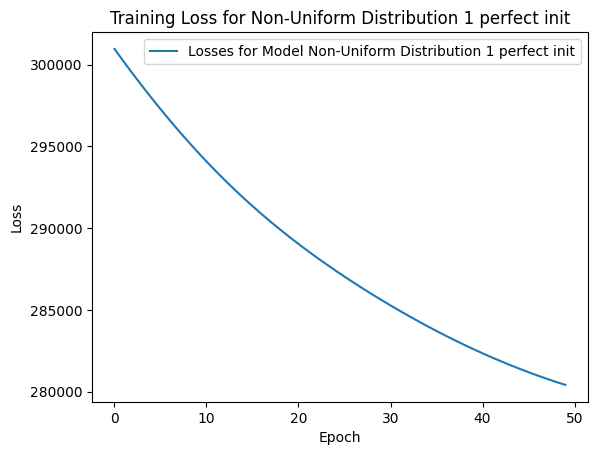

2025-06-19 19:47:25,543 - INFO - Initial Q (logit/softmax):
[[-2.3014]
 [-1.6077]
 [-1.2139]
 [-0.9101]]

[[0.1001]
 [0.2004]
 [0.297 ]
 [0.4025]],

Trained Q (logit/softmax):
[[-1.8447]
 [-1.5241]
 [-1.5337]
 [-1.3459]]

[[0.1855]
 [0.2557]
 [0.2532]
 [0.3055]]
2025-06-19 19:47:25,545 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-19 19:47:25,546 - INFO - Relative frequencies of nucleotides in generated data:
[0.1001 0.2004 0.297  0.4025]


In [13]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1 perfect init", lr=0.01, perfect_initialization=True)

Vermutung: Verteilung `[A: 0.1, C: 0.2, G: 0.3, T: 0.4]` wird nicht gelernt, da das in den RC-Sequenzen zu 
`[A: 0.4, C: 0.3, G: 0.2, T: 0.1]` führt. Bei asymmetrischen Verteilungen könnten aber zwei zu lernende Modelle mit 
gleichen Gewichten funktionieren

2025-06-19 19:47:25,567 - INFO - Testing model Non-Uniform Distribution 2, v2 with parameters: [0.1 0.2 0.3 0.4] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=2
2025-06-19 19:47:26,184 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:47:26,228 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.0998 0.1983 0.3014 0.4006]
2025-06-19 19:47:26,238 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:47:26,265 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 2), m_logit shape: (2,)
2025-06-19 19:47:26,290 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-19 19:47:27.525481: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:47:27,531 - INFO - [background_model.train] >>> epoch     0 mean loss = 270594.9375, time: 1.24s
2025-06-19 19:47:27,532 - DEBUG - [background_m

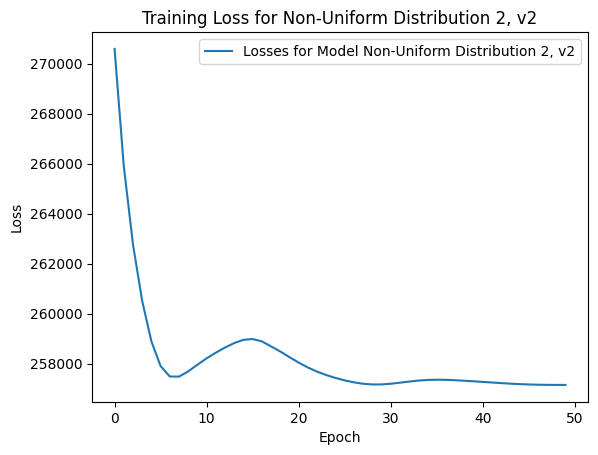

2025-06-19 19:47:58,923 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118]
 [-0.0294 -0.0071]
 [-0.0933  0.0369]
 [ 0.048   0.0745]]

[[0.2607 0.2413]
 [0.2449 0.2424]
 [0.2298 0.2533]
 [0.2646 0.263 ]],

Trained Q (logit/softmax):
[[ 0.7154 -0.7168]
 [ 0.437  -0.0172]
 [ 0.0066  0.4179]
 [-0.6703  0.6994]]

[[0.4001 0.0976]
 [0.3029 0.1965]
 [0.1969 0.3036]
 [0.1001 0.4023]]
2025-06-19 19:47:58,925 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031]

[0.5102 0.4898],

Trained m (logit/softmax):
[0.0213 0.0132]

[0.502 0.498]
2025-06-19 19:47:58,927 - INFO - Relative frequencies of nucleotides in generated data:
[0.0998 0.1983 0.3014 0.4006]


In [14]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 2, v2", lr=0.1, epochs=50, N=1000, seqlen=100, batch_size=1, K=2)

2025-06-19 19:47:58,945 - INFO - Testing model Non-Uniform Distribution 2 with parameters: [0.1 0.4 0.4 0.1] and hyperparameters lr=0.1, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:47:59,492 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:47:59,530 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.099  0.4018 0.3994 0.0999]
2025-06-19 19:47:59,538 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:47:59,555 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:47:59,582 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-19 19:48:00.709829: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:48:00,713 - INFO - [background_model.train] >>> epoch     0 mean loss = 267946.9375, time: 1.13s
2025-06-19 19:48:00,714 - DEBUG - [background_model

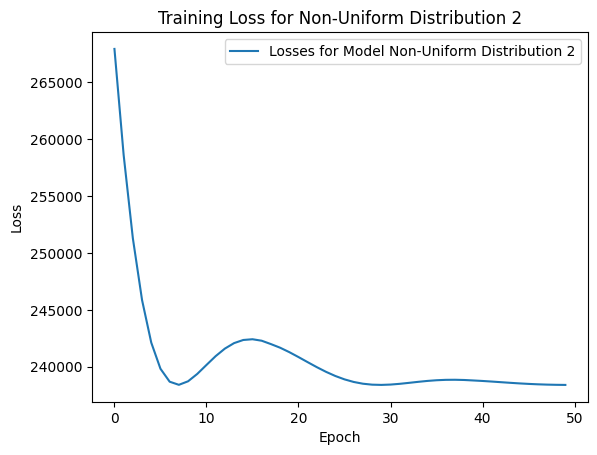

2025-06-19 19:48:28,023 - INFO - Initial Q (logit/softmax):
[[ 0.0329]
 [-0.0118]
 [-0.0294]
 [-0.0071]]

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]],

Trained Q (logit/softmax):
[[-0.6892]
 [ 0.6875]
 [ 0.6864]
 [-0.6993]]

[[0.1009]
 [0.3998]
 [0.3994]
 [0.0999]]
2025-06-19 19:48:28,025 - INFO - Initial m (logit/softmax):
[0.0376]

[1.],

Trained m (logit/softmax):
[0.0376]

[1.]
2025-06-19 19:48:28,026 - INFO - Relative frequencies of nucleotides in generated data:
[0.099  0.4018 0.3994 0.0999]


In [15]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2")

2025-06-19 19:48:28,043 - INFO - Testing model Non-Uniform Distribution 2 perfect init with parameters: [0.1 0.4 0.4 0.1] and hyperparameters lr=0.01, epochs=50, N=1000, seqlen=100, tile_size=100, batch_size=1, K=1
2025-06-19 19:48:28,539 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:48:28,577 - INFO - [generate_data] Relative frequencies of nucleotides in generated data: [0.1004 0.4028 0.3987 0.0981]
2025-06-19 19:48:28,587 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:48:28,610 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-19 19:48:28,635 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-19 19:48:29.838182: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-19 19:48:29,841 - INFO - [background_model.train] >>> epoch     0 mean loss = 238291.8438, time: 1.20s
2025-06-19 19:48:29,842 - DEBUG - [b

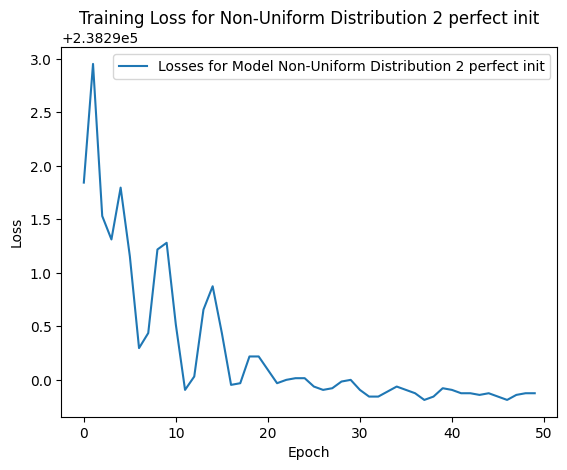

2025-06-19 19:48:57,580 - INFO - Initial Q (logit/softmax):
[[-2.2983]
 [-0.9093]
 [-0.9195]
 [-2.3222]]

[[0.1004]
 [0.4028]
 [0.3987]
 [0.0981]],

Trained Q (logit/softmax):
[[-2.3096]
 [-0.9147]
 [-0.9139]
 [-2.3109]]

[[0.0993]
 [0.4006]
 [0.4009]
 [0.0992]]
2025-06-19 19:48:57,582 - INFO - Initial m (logit/softmax):
[1.]

[1.],

Trained m (logit/softmax):
[1.]

[1.]
2025-06-19 19:48:57,585 - INFO - Relative frequencies of nucleotides in generated data:
[0.1004 0.4028 0.3987 0.0981]


In [16]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2 perfect init", lr=0.01, perfect_initialization=True)

---

In [17]:
def generate_mixed_data(models: list[np.ndarray], weights: list[float], N: int, seqlen: int, tile_size: int, 
                        batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(models) == len(weights), "Number of models must match number of weights."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    for model in models:
        assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    chosen_models = []
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(len(models)), weights=weights, k=1)[0]
        model = models[mi]
        # Generate a sequence using the chosen model
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
        chosen_models.append(mi)

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
    for i, seq in enumerate(raw_data):
        mi = chosen_models[i]
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[mi][ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
            
    return data, relative_frequencies

In [18]:
def multi_model_test(ground_truths: list[np.ndarray], weights: list[float], name: str, 
                     lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                     batch_size: int = batch_size, perfect_initialization: bool = False):
    """ perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    assert len(ground_truths) >= 1, "At least one ground truth model is required for multi-model testing."
    assert len(ground_truths) == len(weights), "Number of ground truth models must match number of weights."
    K = len(ground_truths)
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_mixed_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
        model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(data, lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}\n\nwith weights:\n{weights}")

2025-06-19 19:48:57,715 - INFO - Testing model Mixed Model 1 with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.2, 0.3, 0.4]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.1, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=3
2025-06-19 19:48:58,251 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:48:58,287 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.2451, 0.2504, 0.2496, 0.2549]), array([0.0958, 0.199 , 0.3007, 0.4045]), array([0.0997, 0.402 , 0.4008, 0.0975])]
2025-06-19 19:48:58,294 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:48:58,312 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 3), m_logit shape: (3,)
2025-06-19 19:48:58,331 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.1
2025-06-19 19:48:59.340308: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06

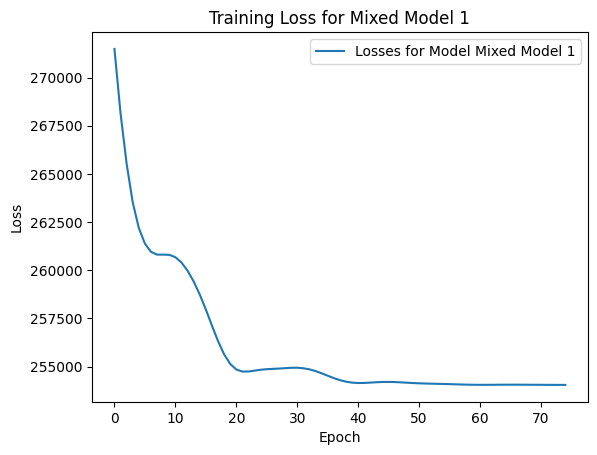

2025-06-19 19:49:49,570 - INFO - Initial Q (logit/softmax):
[[ 0.0329 -0.0118 -0.0294]
 [-0.0071 -0.0933  0.0369]
 [ 0.048   0.0745 -0.0547]
 [-0.0554 -0.0379  0.0445]]

[[0.257  0.2509 0.2427]
 [0.2469 0.2312 0.2594]
 [0.2609 0.2735 0.2366]
 [0.2353 0.2444 0.2613]]
2025-06-19 19:49:49,573 - INFO - Initial m (logit/softmax):
[ 0.0376 -0.0031  0.0862]

[0.3322 0.319  0.3488]
2025-06-19 19:49:49,576 - INFO - Trained Q (logit/softmax):
[[ 0.5434 -0.7289 -0.3493]
 [ 0.2506  0.6938 -0.0789]
 [-0.081   0.6947  0.1309]
 [-0.6459 -0.7153  0.3083]]

[[0.3867 0.097  0.1707]
 [0.2885 0.4022 0.2237]
 [0.2071 0.4026 0.276 ]
 [0.1177 0.0983 0.3295]]
2025-06-19 19:49:49,578 - INFO - Trained m (logit/softmax):
[-0.6082  0.3552 -0.1663]

[0.1932 0.5063 0.3005]
2025-06-19 19:49:49,581 - INFO - Relative frequencies of nucleotides in generated data:
[array([0.2451, 0.2504, 0.2496, 0.2549]), array([0.0958, 0.199 , 0.3007, 0.4045]), array([0.0997, 0.402 , 0.4008, 0.0975])]

with weights:
[0.2, 0.3, 0.5]


In [19]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

2025-06-19 19:49:49,604 - INFO - Testing model Mixed Model 1 perfect init with parameters: [array([0.25, 0.25, 0.25, 0.25]), array([0.1, 0.2, 0.3, 0.4]), array([0.1, 0.4, 0.4, 0.1])] and hyperparameters lr=0.01, epochs=75, N=1000, seqlen=100, tile_size=100, batch_size=1, K=3
2025-06-19 19:49:50,624 - DEBUG - [generate_data] Steps per epoch: 1.
2025-06-19 19:49:50,675 - INFO - [generate_data] Relative frequencies of nucleotides in generated data:
[array([0.2542, 0.2499, 0.2493, 0.2465]), array([0.1012, 0.1995, 0.303 , 0.3964]), array([0.1024, 0.3985, 0.401 , 0.0982])]
2025-06-19 19:49:50,687 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-19 19:49:50,710 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 3), m_logit shape: (3,)
2025-06-19 19:49:50,744 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-19 19:49:52.147240: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of s

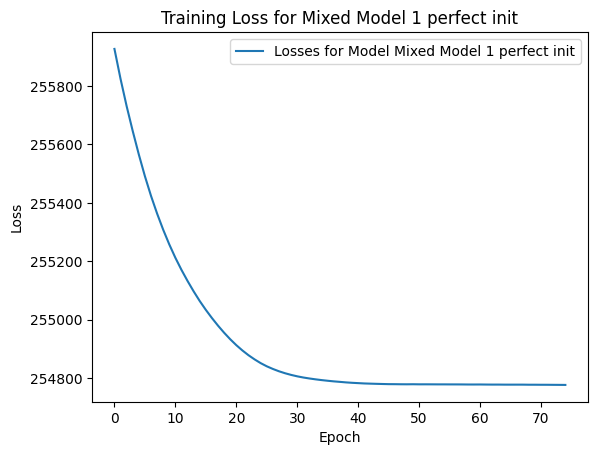

2025-06-19 19:50:34,497 - INFO - Initial Q (logit/softmax):
[[-1.3695 -2.291  -2.2793]
 [-1.3865 -1.612  -0.9201]
 [-1.3892 -1.1942 -0.9139]
 [-1.4003 -0.9254 -2.3209]]

[[0.2542 0.1012 0.1024]
 [0.2499 0.1995 0.3985]
 [0.2493 0.303  0.401 ]
 [0.2465 0.3964 0.0982]]
2025-06-19 19:50:34,498 - INFO - Initial m (logit/softmax):
[-1.6094 -1.204  -0.6931]

[0.2 0.3 0.5]
2025-06-19 19:50:34,499 - INFO - Trained Q (logit/softmax):
[[-1.0759 -2.1171 -2.3002]
 [-1.2451 -1.5915 -0.9181]
 [-1.4491 -1.2466 -0.9177]
 [-1.7071 -1.006  -2.2998]]

[[0.3263 0.1232 0.1003]
 [0.2755 0.2084 0.3996]
 [0.2247 0.2942 0.3997]
 [0.1736 0.3742 0.1004]]
2025-06-19 19:50:34,501 - INFO - Trained m (logit/softmax):
[-1.1579 -1.6367 -0.5566]

[0.2904 0.1799 0.5298]
2025-06-19 19:50:34,502 - INFO - Relative frequencies of nucleotides in generated data:
[array([0.2542, 0.2499, 0.2493, 0.2465]), array([0.1012, 0.1995, 0.303 , 0.3964]), array([0.1024, 0.3985, 0.401 , 0.0982])]

with weights:
[0.2, 0.3, 0.5]


In [20]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1 perfect init", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, perfect_initialization=True)

---

In [21]:
import itertools

def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
                               tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(model.shape) == 2, \
        "Model must be a 2D array for higher order Markov models. First dimension is 4^(order+1), " \
            + f"second dimension is K (number of models). Got shape: {model.shape}."
    num_models = model.shape[1]
    assert len(weights) == num_models, \
        f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
            + f"Got {len(weights)}."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
    # model.shape[0] = 4^k, so k = log4(model.shape[0]) = log2(model.shape[0]) / log2(4) = log2(model.shape[0]) / 2
    k: float = np.log2(model.shape[0]) / 2
    assert k.is_integer(), f"Model must be a higher order Markov model with k-mer alphabet. " \
        + f"Expected 4^k rows for some integer k, but got {model.shape[0]}."
    assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
    k = int(k)
    assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
    order = k - 1
    new_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)] # 4^k k-mer alphabet
    assert len(new_alphabet) == 4**k, f"Alphabet size must be 4^k for k={k}, but got {len(new_alphabet)}."

    # in each column of the model, the 4^k rows correspond to relative k-mer frequencies
    # to determine the next single character, we need a 0-order model for each k-1-mer
    jmer_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k-1)] if k > 1 \
                    else [c for c in alphabet]
    zero_models = {
        jmer: model[[new_alphabet.index(jmer + c) for c in alphabet], :] for jmer in jmer_alphabet
    }
    # normalize the models to get relative frequencies
    for jmer in jmer_alphabet:
        zero_models[jmer] /= np.sum(zero_models[jmer], axis=0, keepdims=True)

    # Generate random sequences based on the provided models
    raw_data = []
    chosen_models = []
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(num_models), weights=weights, k=1)[0]
        init_kmer_idx = random.choices(range(len(new_alphabet)), weights=model[:, mi], k=1)[0]

        seq = new_alphabet[init_kmer_idx]  # Start with a random k-mer
        for i in range(k, seqlen-k+1):  # Generate the rest of the sequence
            # Get the last k-1 characters to determine the next character
            jmer = seq[i-k+1:i]
            # Get the zero-order model for this j-mer
            zero_model = zero_models[jmer][:, mi]
            # Choose the next character based on the zero-order model
            next_char = random.choices(alphabet, weights=zero_model, k=1)[0]
            seq += next_char
        
        # Append the sequence to the data list
        raw_data.append(seq)
        chosen_models.append(mi)

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # # count the relative frequencies of the nucleotides in the generated sequences for verification
    # counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
    # for i, seq in enumerate(raw_data):
    #     mi = chosen_models[i]
    #     for c in seq:
    #         assert c in alphabet, \
    #             f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
    #         ci = alphabet.index(c)
    #         counts[mi][ci] += 1

    # # Calculate the relative frequencies
    # relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
    # logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
    _, relative_frequencies, _ = background_model.get_background_model(order=order, model_type="data", src=raw_data)
    return data, relative_frequencies

In [25]:
generate_higher_order_data(
    np.array([[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]),
    [0.3, 0.7],
    N=2, seqlen=10, tile_size=10, batch_size=1, alphabet="ACGT"
)

AssertionError: Number of weights must match number of models in the higher order Markov model, which is 16. Got 2.

---

In [ ]:
assert False, "Stop here"

AssertionError: Stop here

In [ ]:
np.log(1e-10)